# JVPs, VJPs, and higher-order derivatives

CPU companion; no accelerator is required. TPU execution not validated.

- Compute and interpret JVP and VJP products with correct domains and shapes.
- Verify the adjoint dot-product identity against a hand-derived Jacobian.
- Compute an exact Hessian-vector product and distinguish it from a Gauss–Newton approximation.

A large model may have millions of inputs or outputs, but you often need only one sensitivity direction. How can we compute the useful product without constructing the full Jacobian—and verify that forward, reverse and higher-order calculations agree?

## The idea

A JVP asks how an input direction changes outputs. A VJP asks how an output sensitivity pulls back to inputs. Both use the same local derivative, but their vectors belong to different spaces.

## Forward and reverse products answer complementary questions

For a map from three inputs to two outputs, the Jacobian has shape $(2,3)$. A JVP consumes a three-component direction and returns two components. A VJP consumes a two-component cotangent and returns three.

Check the adjoint relation $u^T(Jv)=(J^Tu)^Tv$ using independent dot products. It connects both directions without requiring the full Jacobian to be materialized.

When reading product bars, name the vector's space before interpreting its coordinates. A square example can hide a transpose mistake because both vectors have the same length. Add an unequal-dimension case to expose that ambiguity.

### JVP and VJP use different vector spaces

**Predict:** Does a VJP simply return the same vector as a JVP?

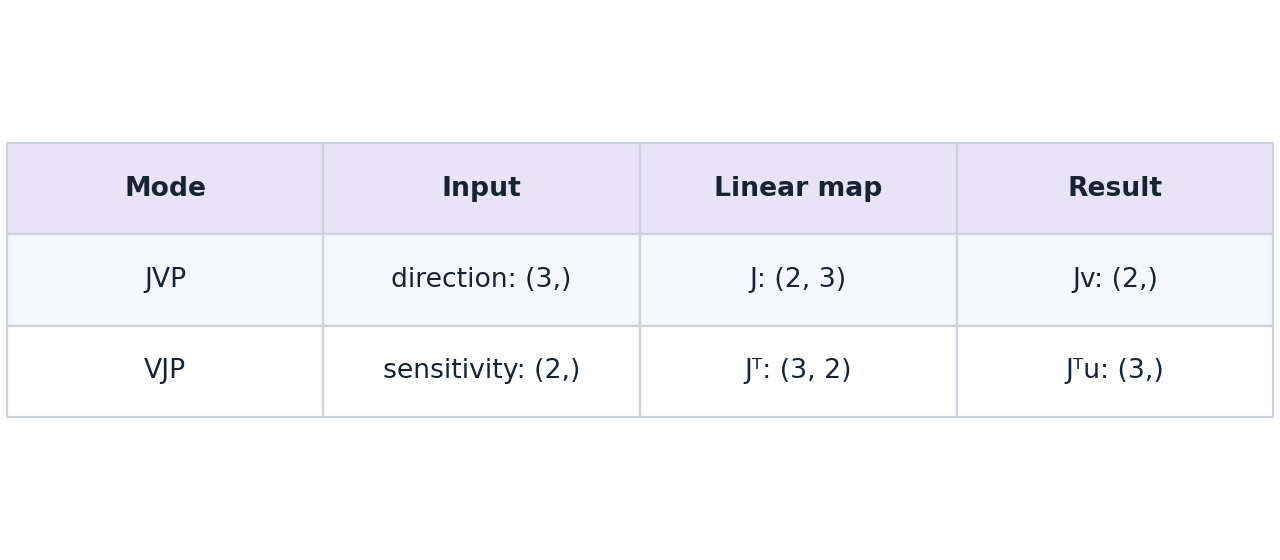

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

The top row pushes a three-component direction into two output components. The bottom pulls a two-component sensitivity back to three inputs. Shapes disambiguate the two products even when a square worked example would not. The adjoint identity checks their relationship.

### Pause and reason

Does a VJP simply return the same vector as a JVP?

<details><summary>Compare your reasoning</summary>

No. They apply the derivative in different directions and can have different result dimensions. Their relationship is the adjoint identity, not equality of vectors.

</details>

## Separate the point from the direction

For $f(a,b)=(ab,\sin(a)+b^2)$, the point $x=(0.4,-0.7)$ determines a Jacobian. The direction $v=(1.2,-0.3)$ says how the inputs will move near that point. JVP returns both the original output and $J(x)v$. It does not evaluate the nonlinear function at $x+v$; its approximation becomes meaningful when multiplied by a sufficiently small displacement.

$$
J(a,b)=\begin{bmatrix}b&a\\\cos(a)&2b\end{bmatrix},\qquad f(x+\varepsilon v)\approx f(x)+\varepsilon J(x)v
$$

## A VJP answers a different directional question

The cotangent $u=(0.5,2)$ weights changes in the two outputs. Pulling it back gives $J(x)^\mathsf{T}u$, a vector in input space. It is the gradient of the scalar function $u^\mathsf{T}f(x)$ when $u$ is fixed. The pullback closes over the forward computation at this specific point; it must be rebuilt when the point changes.

## Check the adjoint identity with independent values

The scalar $u^\mathsf{T}(Jv)$ can be computed either by pushing the direction first or pulling the measurement first. The two orders must agree: $u^\mathsf{T}Jv=(J^\mathsf{T}u)^\mathsf{T}v$. Here JVP is approximately $(-0.96,1.52527)$, VJP is $(1.49212,-2.6)$, and both scalar products are about $2.57055$. This identity alone is insufficient if both rules share a mistake; the explicit Jacobian adds an independent oracle.

## Count directions before choosing a Jacobian strategy

Forward mode naturally produces a Jacobian column for each input basis direction; reverse mode produces a row for each output basis direction. Many inputs and one scalar output often favor reverse mode, whereas a small number of input directions may favor forward products. Real runtime also depends on intermediates, batching and device behavior. This lesson verifies mathematical products, not a universal timing rule.

## Curvature includes the changing Jacobian

For $L(x)=\frac12\lVert f(x)\rVert^2$, the gradient is $J^\mathsf{T}f$. Differentiating again gives $H=J^\mathsf{T}J+\sum_i f_i\nabla^2f_i$. The first term is positive semidefinite and is often used as a Gauss–Newton approximation; it is exact only when the residual-weighted term vanishes. Forward-over-reverse differentiation computes $Hv$ without building every Hessian entry.

$$
Hv=J^\mathsf{T}(Jv)+\sum_i f_i(\nabla^2 f_i)v
$$

## Use finite differences as a second perspective

A central difference of gradients approximates the Hessian-vector product, while a central difference of function outputs approximates the JVP. Sweep perturbations and retain a range of agreement; making the perturbation arbitrarily small causes cancellation. Float64 is explicitly enabled for these CPU comparisons. Non-smooth points and custom derivative rules require their own mathematical interpretation.

## Define a small vector map and derive its Jacobian

Create main.py for the first block, then append subsequent blocks in order using your course CPU environment.

In [1]:
# Step 1 — Define a small vector map and derive its Jacobian: The map has two inputs and two outputs.
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_enable_x64", True)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np

# Function `mapping(x)` implementing this stage's computation:
def mapping(x):
    # Evaluate `(a, b)` from the current inputs and state.
    a,b=x
    # Return `jnp.array([a * b, jnp.sin(a) + b * b])` to the caller.
    return jnp.array([a*b,jnp.sin(a)+b*b])
# Initialize array `x` with explicit values and shape.
x=jnp.array([0.4,-0.7])
# Initialize array `v` with explicit values and shape.
v=jnp.array([1.2,-0.3])
# Initialize array `u` with explicit values and shape.
u=jnp.array([0.5,2.0])
# Convert `(a, b)` to a host NumPy array for inspection or verification.
a,b=np.asarray(x)
# Initialize array `jacobian` with explicit values and shape.
jacobian=np.array([[b,a],[np.cos(a),2*b]])
# Initialize array `expected_value` with explicit values and shape.
expected_value=np.array([a*b,np.sin(a)+b*b])

The map has two inputs and two outputs. Its Jacobian rows correspond to output coordinates, and columns to input coordinates.

## Push a direction forward and pull a measurement backward

Create main.py for the first block, then append subsequent blocks in order using your course CPU environment.

In [2]:
# Step 2 — Push a direction forward and pull a measurement backward: The VJP returns one cotangent per input argument, hence the...
# Compute exact directional derivative / Jacobian / Hessian (`(value, jvp)`).
value,jvp=jax.jvp(mapping,(x,),(v,))
# Compute exact directional derivative / Jacobian / Hessian (`(value_again, pullback)`).
value_again,pullback=jax.vjp(mapping,x)
# Run `pullback` to compute `(vjp,)`.
vjp,=pullback(u)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(value,expected_value,rtol=1e-12)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(jvp,jacobian@np.asarray(v),rtol=1e-12)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(vjp,jacobian.T@np.asarray(u),rtol=1e-12)
# Evaluate `jnp.vdot(u, jvp)` and convert the result into Python scalar/collection `left`.
# Evaluate `jnp.vdot(vjp, v)` and convert the result into Python scalar/collection `right`.
left=float(jnp.vdot(u,jvp));right=float(jnp.vdot(vjp,v))
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(left,right,rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Jacobian:",jacobian)
# Print diagnostic summary of the computed outputs.
print("JVP:",np.asarray(jvp),"VJP:",np.asarray(vjp),"adjoint pair:",left,right)

Jacobian: [[-0.7         0.4       ]
 [ 0.92106099 -1.4       ]]
JVP: [-0.96        1.52527319] VJP: [ 1.49212199 -2.6       ] adjoint pair: 2.570546385606924 2.570546385606924


The VJP returns one cotangent per input argument, hence the one-element tuple. The dot-product identity checks that forward and reverse products represent adjoint linear maps.

## Compute curvature without materializing a Hessian

Create main.py for the first block, then append subsequent blocks in order using your course CPU environment.

In [3]:
# Step 3 — Compute curvature without materializing a Hessian: For squared residuals, the Hessian includes a...
def objective(z):
    # Return `0.5 * jnp.vdot(mapping(z), mapping(z))` to the caller.
    return 0.5*jnp.vdot(mapping(z),mapping(z))
# Differentiate the objective to obtain `gradient` via automatic differentiation.
gradient=jax.grad(objective)(x)
# Differentiate the objective to obtain `hvp` via automatic differentiation.
hvp=jax.jvp(jax.grad(objective),(x,),(v,))[1]
# Evaluate `y` from the current inputs and state.
y=expected_value
# Initialize array `hessian_0` with explicit values and shape.
hessian_0=np.array([[0.,1.],[1.,0.]])
# Initialize array `hessian_1` with explicit values and shape.
hessian_1=np.array([[-np.sin(a),0.],[0.,2.]])
# Perform matrix contraction / projection to compute `hessian`.
hessian=jacobian.T@jacobian+y[0]*hessian_0+y[1]*hessian_1
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(gradient,jacobian.T@y,rtol=1e-12)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(hvp,hessian@np.asarray(v),rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(hessian,hessian.T,atol=1e-12)
# Print diagnostic summary of the computed outputs.
print("Hessian-vector product:",np.asarray(hvp))

Hessian-vector product: [ 1.74991568 -3.38303348]


For squared residuals, the Hessian includes a Jacobian-transpose-Jacobian term and residual-weighted second derivatives. Dropping the latter is an approximation, not the exact Hessian.

## Run the example

In [4]:
# Step 1 — Define a small vector map and derive its Jacobian: The map has two inputs and two outputs.
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_enable_x64", True)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np

# Function `mapping(x)` implementing this stage's computation:
def mapping(x):
    # Evaluate `(a, b)` from the current inputs and state.
    a,b=x
    # Return `jnp.array([a * b, jnp.sin(a) + b * b])` to the caller.
    return jnp.array([a*b,jnp.sin(a)+b*b])
# Initialize array `x` with explicit values and shape.
x=jnp.array([0.4,-0.7])
# Initialize array `v` with explicit values and shape.
v=jnp.array([1.2,-0.3])
# Initialize array `u` with explicit values and shape.
u=jnp.array([0.5,2.0])
# Convert `(a, b)` to a host NumPy array for inspection or verification.
a,b=np.asarray(x)
# Initialize array `jacobian` with explicit values and shape.
jacobian=np.array([[b,a],[np.cos(a),2*b]])
# Initialize array `expected_value` with explicit values and shape.
expected_value=np.array([a*b,np.sin(a)+b*b])

# Step 2 — Push a direction forward and pull a measurement backward: The VJP returns one cotangent per input argument, hence the...
# Compute exact directional derivative / Jacobian / Hessian (`(value, jvp)`).
value,jvp=jax.jvp(mapping,(x,),(v,))
# Compute exact directional derivative / Jacobian / Hessian (`(value_again, pullback)`).
value_again,pullback=jax.vjp(mapping,x)
# Run `pullback` to compute `(vjp,)`.
vjp,=pullback(u)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(value,expected_value,rtol=1e-12)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(jvp,jacobian@np.asarray(v),rtol=1e-12)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(vjp,jacobian.T@np.asarray(u),rtol=1e-12)
# Evaluate `jnp.vdot(u, jvp)` and convert the result into Python scalar/collection `left`.
# Evaluate `jnp.vdot(vjp, v)` and convert the result into Python scalar/collection `right`.
left=float(jnp.vdot(u,jvp));right=float(jnp.vdot(vjp,v))
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(left,right,rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Jacobian:",jacobian)
# Print diagnostic summary of the computed outputs.
print("JVP:",np.asarray(jvp),"VJP:",np.asarray(vjp),"adjoint pair:",left,right)

# Step 3 — Compute curvature without materializing a Hessian: For squared residuals, the Hessian includes a...
def objective(z):
    # Return `0.5 * jnp.vdot(mapping(z), mapping(z))` to the caller.
    return 0.5*jnp.vdot(mapping(z),mapping(z))
# Differentiate the objective to obtain `gradient` via automatic differentiation.
gradient=jax.grad(objective)(x)
# Differentiate the objective to obtain `hvp` via automatic differentiation.
hvp=jax.jvp(jax.grad(objective),(x,),(v,))[1]
# Evaluate `y` from the current inputs and state.
y=expected_value
# Initialize array `hessian_0` with explicit values and shape.
hessian_0=np.array([[0.,1.],[1.,0.]])
# Initialize array `hessian_1` with explicit values and shape.
hessian_1=np.array([[-np.sin(a),0.],[0.,2.]])
# Perform matrix contraction / projection to compute `hessian`.
hessian=jacobian.T@jacobian+y[0]*hessian_0+y[1]*hessian_1
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(gradient,jacobian.T@y,rtol=1e-12)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(hvp,hessian@np.asarray(v),rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(hessian,hessian.T,atol=1e-12)
# Print diagnostic summary of the computed outputs.
print("Hessian-vector product:",np.asarray(hvp))

Jacobian: [[-0.7         0.4       ]
 [ 0.92106099 -1.4       ]]
JVP: [-0.96        1.52527319] VJP: [ 1.49212199 -2.6       ] adjoint pair: 2.570546385606924 2.570546385606924
Hessian-vector product: [ 1.74991568 -3.38303348]


Expected: JVP [-0.96, 1.52527319], VJP [1.49212199, -2.6], adjoint scalar approximately 2.57054639. The independently derived Hessian-vector product agrees.

## Forward and reverse products live in different spaces

Predict: Should a JVP and VJP have equal coordinates just because this example has two inputs and two outputs?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Forward and reverse products live in different spaces
# Convert `visual_data` to a host NumPy array for inspection or verification.
visual_data={'panels':[{'kind':'bar','labels':['output 0','output 1'],'ylabel':'directional output change','series':[{'label':'JAX JVP','y':np.asarray(jvp).tolist()},{'label':'analytic J v','y':(jacobian@np.asarray(v)).tolist()}]},{'kind':'bar','labels':['input 0','input 1'],'ylabel':'input cotangent','series':[{'label':'JAX VJP','y':np.asarray(vjp).tolist()},{'label':'analytic transpose J u','y':(jacobian.T@np.asarray(u)).tolist()}]}]}

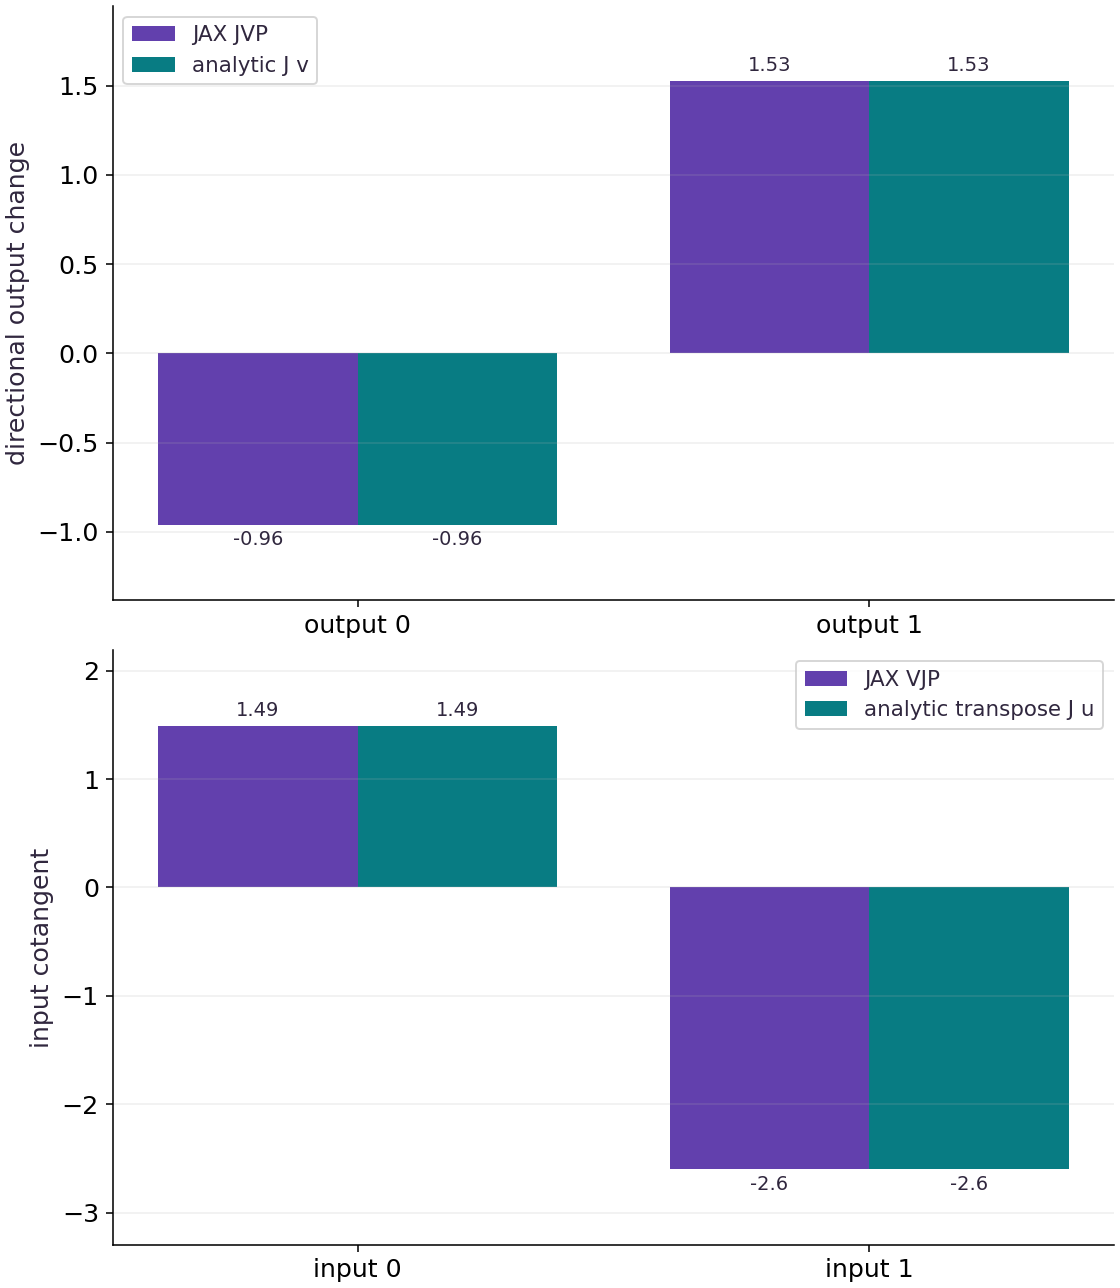

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The first panel compares the JVP with the explicit product $Jv$, one bar per output coordinate. The matched values are about $-0.96$ and $1.5253$. These are predicted output changes for the selected input direction, not the function outputs themselves.

The second panel compares the VJP with $J^\mathsf{T}u$, one bar per input coordinate. Its matched values are about $1.4921$ and $-2.6$. Both plots happen to contain two coordinates, but their axes refer to different vector spaces.

### Connect it to the computation

The bars agree within each panel because the hand-derived Jacobian verifies the corresponding JAX product. The two panels should not agree with each other: their seed vectors and meanings differ. Multiplying by the opposite seed gives the common adjoint scalar, about $2.5705$.

An adjoint equality checks compatibility between two linear maps. The independent Jacobian and changed-point exercises protect against a shared wrong map. The figure does not compare runtime or memory use.

## Reconstruct columns and rows independently

Predict: Will mapping JVPs over basis vectors directly produce rows or columns?

In [7]:
# Experiment — Reconstruct columns and rows independently: The transpose in the forward construction is necessary: vmap...
# Initialize array `basis` with explicit values and shape.
basis=jnp.eye(2)
# Compute exact directional derivative / Jacobian / Hessian (`columns`).
columns=jax.vmap(lambda direction:jax.jvp(mapping,(x,),(direction,))[1])(basis).T
# Vectorize across the batch dimension with `jax.vmap` (`rows`).
rows=jax.vmap(lambda weighting:pullback(weighting)[0])(basis)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(columns,jacobian,rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(rows,jacobian,rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Forward columns and reverse rows agree")

Forward columns and reverse rows agree


Expected: Both reconstructed matrices equal the hand-derived Jacobian.

The transpose in the forward construction is necessary: vmap first stacks one directional result per input basis vector.

## Separate exact curvature from Gauss–Newton

Predict: Will the residual-weighted correction vanish at our chosen point?

In [8]:
# Experiment — Separate exact curvature from Gauss–Newton: Residuals are nonzero, and both output functions have second...
# Perform matrix / vector contraction (`@`) to compute `gauss_newton`.
gauss_newton=jacobian.T@jacobian
# Perform matrix / vector contraction (`@`) to compute `approximation`.
approximation=gauss_newton@np.asarray(v)
# Verify contract: `np.linalg.norm(np.asarray(hvp) - approximation) > 0.1`.
assert np.linalg.norm(np.asarray(hvp)-approximation)>0.1
# Evaluate `eps` from the current inputs and state.
eps=1e-4
# Differentiate the objective to obtain `fd` via automatic differentiation.
fd=(np.asarray(jax.grad(objective)(x+eps*v))-np.asarray(jax.grad(objective)(x-eps*v)))/(2*eps)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(hvp,fd,rtol=1e-7,atol=1e-8)
# Print the observed values to compare against the expected result.
print("Exact HVP:",np.asarray(hvp),"Gauss-Newton product:",approximation)

Exact HVP: [ 1.74991568 -3.38303348] Gauss-Newton product: [ 2.07686964 -2.51938247]


Expected: The approximation differs visibly; the finite-difference gradient check matches the exact HVP.

Residuals are nonzero, and both output functions have second derivatives. Calling the approximation the Hessian would erase those contributions.

## Your exercise

Repeat the Jacobian, JVP, VJP and adjoint checks at $x=(-0.2,0.8)$ with $v=(-0.5,1.3)$ and $u=(1.1,-0.4)$. Explain which quantities belong to input and output space.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jvp / jax.vjp / jax.jacfwd / jax.hessian` — Computes exact forward-mode JVP, reverse-mode VJP, full Jacobians, or second-order curvature.

**Step-by-step implementation plan:**
1. Initialize array `changed_x` with explicit values and shape.
2. Convert `(a2, b2)` to a host NumPy array for inspection or verification.
3. Initialize array `j2` with explicit values and shape.
4. Compute exact directional derivative / Jacobian / Hessian (`fj`).
5. Compute exact directional derivative / Jacobian / Hessian (`rj`).

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Repeat the Jacobian, JVP, VJP and adjoint checks at x=(-0.2,0.8) with...
# Initialize array `changed_x` with explicit values and shape.
changed_x = jnp.array(...)  # TODO: compute changed_x
# Convert `(a2, b2)` to a host NumPy array for inspection or verification.
a2,b2 = np.asarray(...)  # TODO: compute a2,b2
# Initialize array `j2` with explicit values and shape.
j2 = np.array(...)  # TODO: compute j2
# Compute exact directional derivative / Jacobian / Hessian (`fj`).
fj = jax.jvp(...)  # TODO: compute fj
# Compute exact directional derivative / Jacobian / Hessian (`rj`).
rj = jax.vjp(...)  # TODO: compute rj
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(fj,j2@changed_v,rtol=1e-12)
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(rj,j2.T@changed_u,rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(jnp.vdot(changed_u,fj),jnp.vdot(rj,changed_v),rtol = ...  # TODO: compute np.testing.assert_allclose(jnp.vdot(changed_u,fj),jnp.vdot(rj,changed_v),rtol
# Print the observed values to compare against the expected result.
print("Changed-point adjoint verified")
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Repeat the Jacobian, JVP, VJP and adjoint checks at x=(-0.2,0.8) with...
# Initialize array `changed_x` with explicit values and shape.
# changed_x = jnp.array(...)  # TODO: compute changed_x
# Convert `(a2, b2)` to a host NumPy array for inspection or verification.
# a2,b2 = np.asarray(...)  # TODO: compute a2,b2
# Initialize array `j2` with explicit values and shape.
# j2 = np.array(...)  # TODO: compute j2
# Compute exact directional derivative / Jacobian / Hessian (`fj`).
# fj = jax.jvp(...)  # TODO: compute fj
# Compute exact directional derivative / Jacobian / Hessian (`rj`).
# rj = jax.vjp(...)  # TODO: compute rj
# Perform matrix contraction / projection to compute ``.
# np.testing.assert_allclose(fj,j2@changed_v,rtol=1e-12)
# Perform matrix contraction / projection to compute ``.
# np.testing.assert_allclose(rj,j2.T@changed_u,rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(jnp.vdot(changed_u,fj),jnp.vdot(rj,changed_v),rtol = ...  # TODO: compute np.testing.assert_allclose(jnp.vdot(changed_u,fj),jnp.vdot(rj,changed_v),rtol
# Print the observed values to compare against the expected result.
# print("Changed-point adjoint verified")

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Repeat the Jacobian, JVP, VJP and adjoint checks at x=(-0.2,0.8) with...
# Initialize array `changed_x` with explicit values and shape.
changed_x=jnp.array([-0.2,0.8]);changed_v=jnp.array([-0.5,1.3]);changed_u=jnp.array([1.1,-0.4])
# Convert `(a2, b2)` to a host NumPy array for inspection or verification.
a2,b2=np.asarray(changed_x)
# Initialize array `j2` with explicit values and shape.
j2=np.array([[b2,a2],[np.cos(a2),2*b2]])
# Compute exact directional derivative / Jacobian / Hessian (`fj`).
fj=jax.jvp(mapping,(changed_x,),(changed_v,))[1]
# Compute exact directional derivative / Jacobian / Hessian (`rj`).
rj=jax.vjp(mapping,changed_x)[1](changed_u)[0]
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(fj,j2@changed_v,rtol=1e-12)
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(rj,j2.T@changed_u,rtol=1e-12)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(jnp.vdot(changed_u,fj),jnp.vdot(rj,changed_v),rtol=1e-12)
# Print the observed values to compare against the expected result.
print("Changed-point adjoint verified")

Changed-point adjoint verified


## Test linearity at a fixed point · Practice

Check the JVP of $2v-w$ against the same combination of separate JVPs. Then show why changing the base point is a different operation.

Hint: A derivative is linear in its direction at a fixed base point.

### How to write: Test linearity at a fixed point — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jvp / jax.vjp / jax.jacfwd / jax.hessian` — Computes exact forward-mode JVP, reverse-mode VJP, full Jacobians, or second-order curvature.

**Step-by-step implementation plan:**
1. Initialize array `w` with explicit values and shape.
2. Compute exact directional derivative / Jacobian / Hessian (`product`).
3. Verify that computed values match the expected reference within numerical tolerance.
4. Compute exact directional derivative / Jacobian / Hessian (`shifted`).
5. Verify contract: `np.linalg.norm(np.asarray(shifted - product(v))) > 0.1`.

**Starter code scaffold (fill in the TODOs):**

```python
# Test linearity at a fixed point (Practice): Linearity in the tangent is a local property.
# Initialize array `w` with explicit values and shape.
w = jnp.array(...)  # TODO: compute w
# Compute exact directional derivative / Jacobian / Hessian (`product`).
product = ...  # TODO: compute product
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(product(2*v-w),2*product(v)-product(w),rtol=1e-12)
# Compute exact directional derivative / Jacobian / Hessian (`shifted`).
shifted = jax.jvp(...)  # TODO: compute shifted
# Verify contract: `np.linalg.norm(np.asarray(shifted - product(v))) > 0.1`.
assert np.linalg.norm(np.asarray(shifted-product(v)))  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print("Direction linearity holds; the Jacobian changes with the base point")
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Test linearity at a fixed point (Practice): Linearity in the tangent is a local property.
# Initialize array `w` with explicit values and shape.
# w = jnp.array(...)  # TODO: compute w
# Compute exact directional derivative / Jacobian / Hessian (`product`).
# product = ...  # TODO: compute product
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(product(2*v-w),2*product(v)-product(w),rtol=1e-12)
# Compute exact directional derivative / Jacobian / Hessian (`shifted`).
# shifted = jax.jvp(...)  # TODO: compute shifted
# Verify contract: `np.linalg.norm(np.asarray(shifted - product(v))) > 0.1`.
# assert np.linalg.norm(np.asarray(shifted-product(v)))  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print("Direction linearity holds; the Jacobian changes with the base point")

## Reference reasoning

Linearity in the tangent is a local property. A nonlinear function need not use the same linear map at different points.

In [12]:
# Test linearity at a fixed point (Practice): Linearity in the tangent is a local property.
# Initialize array `w` with explicit values and shape.
w=jnp.array([-0.6,0.9])
# Compute exact directional derivative / Jacobian / Hessian (`product`).
product=lambda direction:jax.jvp(mapping,(x,),(direction,))[1]
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(product(2*v-w),2*product(v)-product(w),rtol=1e-12)
# Compute exact directional derivative / Jacobian / Hessian (`shifted`).
shifted=jax.jvp(mapping,(x+w,),(v,))[1]
# Verify contract: `np.linalg.norm(np.asarray(shifted - product(v))) > 0.1`.
assert np.linalg.norm(np.asarray(shifted-product(v)))>0.1
# Print the observed values to compare against the expected result.
print("Direction linearity holds; the Jacobian changes with the base point")

Direction linearity holds; the Jacobian changes with the base point


## Check curvature symmetry without a full Hessian · Challenge

For two directions $v,w$, verify $w^\mathsf{T}Hv=v^\mathsf{T}Hw$, then verify one product with finite differences.

Hint: Compose jvp with grad and compare scalar products.

### How to write: Check curvature symmetry without a full Hessian — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.jvp / jax.vjp / jax.jacfwd / jax.hessian` — Computes exact forward-mode JVP, reverse-mode VJP, full Jacobians, or second-order curvature.

**Step-by-step implementation plan:**
1. Initialize array `w` with explicit values and shape.
2. Differentiate the objective to obtain `hw` via automatic differentiation.
3. Verify that computed values match the expected reference within numerical tolerance.
4. Evaluate `eps` from the current inputs and state.
5. Differentiate the objective to obtain `fdw` via automatic differentiation.

**Starter code scaffold (fill in the TODOs):**

```python
# Check curvature symmetry without a full Hessian (Challenge): For this smooth scalar objective, mixed partials agree.
# Initialize array `w` with explicit values and shape.
w = jnp.array(...)  # TODO: compute w
# Differentiate the objective to obtain `hw` via automatic differentiation.
hw = jax.jvp(...)  # TODO: compute hw
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(jnp.vdot(w,hvp),jnp.vdot(v,hw),rtol = ...  # TODO: compute np.testing.assert_allclose(jnp.vdot(w,hvp),jnp.vdot(v,hw),rtol
# Evaluate `eps` from the current inputs and state.
eps = ...  # TODO: compute eps
# Differentiate the objective to obtain `fdw` via automatic differentiation.
fdw = ...  # TODO: compute fdw
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(hw,fdw,rtol = ...  # TODO: compute np.testing.assert_allclose(hw,fdw,rtol
# Print the observed values to compare against the expected result.
print("Bilinear Hessian symmetry and finite-difference product verified")
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check curvature symmetry without a full Hessian (Challenge): For this smooth scalar objective, mixed partials agree.
# Initialize array `w` with explicit values and shape.
# w = jnp.array(...)  # TODO: compute w
# Differentiate the objective to obtain `hw` via automatic differentiation.
# hw = jax.jvp(...)  # TODO: compute hw
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(jnp.vdot(w,hvp),jnp.vdot(v,hw),rtol = ...  # TODO: compute np.testing.assert_allclose(jnp.vdot(w,hvp),jnp.vdot(v,hw),rtol
# Evaluate `eps` from the current inputs and state.
# eps = ...  # TODO: compute eps
# Differentiate the objective to obtain `fdw` via automatic differentiation.
# fdw = ...  # TODO: compute fdw
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(hw,fdw,rtol = ...  # TODO: compute np.testing.assert_allclose(hw,fdw,rtol
# Print the observed values to compare against the expected result.
# print("Bilinear Hessian symmetry and finite-difference product verified")

## Reference reasoning

For this smooth scalar objective, mixed partials agree. Symmetry is a useful invariant, but an independent derivative check is still necessary.

In [14]:
# Check curvature symmetry without a full Hessian (Challenge): For this smooth scalar objective, mixed partials agree.
# Initialize array `w` with explicit values and shape.
w=jnp.array([0.2,0.9])
# Differentiate the objective to obtain `hw` via automatic differentiation.
hw=jax.jvp(jax.grad(objective),(x,),(w,))[1]
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(jnp.vdot(w,hvp),jnp.vdot(v,hw),rtol=1e-12)
# Evaluate `eps` from the current inputs and state.
eps=1e-4
# Differentiate the objective to obtain `fdw` via automatic differentiation.
fdw=(jax.grad(objective)(x+eps*w)-jax.grad(objective)(x-eps*w))/(2*eps)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(hw,fdw,rtol=1e-7,atol=1e-8)
# Print the observed values to compare against the expected result.
print("Bilinear Hessian symmetry and finite-difference product verified")

Bilinear Hessian symmetry and finite-difference product verified


## Checkpoint

A VJP is seeded with an output weighting u. What does the returned input cotangent represent?

1. The output at a displaced input x+u.
2. The gradient of the scalar weighted output u-transpose f(x), with u fixed.
3. A complete Hessian for every possible loss.

## Diagnose

If a product has the wrong shape, identify whether its seed lives in input or output space. If basis reconstruction is transposed, inspect which index vmap stacks first. If an HVP differs from J-transpose-J times the direction, calculate the residual-weighted second-derivative term before blaming autodiff.

## Evidence

Hand-derived Jacobian/Hessian, adjoint scalar, changed-point checks, finite-difference HVP and a Gauss–Newton distinction. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Separate the point from the direction
- A VJP answers a different directional question
- Check the adjoint identity with independent values
- Count directions before choosing a Jacobian strategy
- Curvature includes the changing Jacobian
- Use finite differences as a second perspective

## Primary references

- [JAX automatic differentiation cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)
- [Custom JVP and VJP rules](https://docs.jax.dev/en/latest/notebooks/Custom_derivative_rules_for_Python_code.html)
- [Ahead-of-time lowering and compilation](https://docs.jax.dev/en/latest/aot.html)
- [The jaxpr language](https://docs.jax.dev/en/latest/601/jaxpr.html)